In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import re
import nltk
import emoji
import contractions

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize, word_tokenize
from collections import Counter
from langdetect import detect, LangDetectException
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [73]:
# set up -> colour scheme
colours = ["#0B3954", "#087E8B", "#BFD7EA", "#FF5A5F", "#C81D25"]
colmap = {1: colours[4], 2: colours[3], 3: colours[2], 4: colours[1], 5: colours[0]}
sent_colmap = {0: colours[3], 1: colours[1]}
cust_cmap = LinearSegmentedColormap.from_list("custom", ["#BFD7EA", "#FF5A5F"])

**Scenario:**\
The medical aid has noticed that they are receiving quite a few negative reviews on Hello Peter. They are interested to find out what the main areas of concern are and to have a general sentiment of how their customer base is currently experiencing their services.\
They have asked that you conduct a text analysis to first identify broad areas of concern and then analyse the customer sentiments. 

# 1. THE DATASET
The dataset was created by scraping Google reviews from 5 different South African medical aid providers with similar ratings (between 2 and 3) for consistency. Reviews were taken from multiple providers to provide a sufficient sample size for the project. They will be treated as they come from the single provider in this scenario.

Download the dataset here: [medical_aid_google-reviews.csv](https://api.apify.com/v2/datasets/XAK2lZvTJmoSdgPvT/items?signature=MC4xNzgyOTQwNjQwNDk4LjFnWlROYzdQZER1YkxZTWxhTkdPdg&format=csv&fields=reviewId%2Cstars%2Ctext%2Ctitle%2CpublishedAtDate&clean=true&attachment=true)

In [74]:
df = pd.read_csv("medical_aid_google_reviews.csv")

## Dataset: Structure, Missing Values & Duplicates
The dataset has 5 features: reviewId, stars, text, title (company name), and published date. There are 1519 reviews, but there are 404 reviews with no text.\
There are no duplicates in the dataset. After removing textless reviews, there  are **1115** samples left in the dataset. There are no duplicates.

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1519 entries, 0 to 1518
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   reviewId         1519 non-null   object
 1   stars            1519 non-null   int64 
 2   text             1115 non-null   object
 3   title            1519 non-null   object
 4   publishedAtDate  1519 non-null   object
dtypes: int64(1), object(4)
memory usage: 59.5+ KB


In [76]:
df.drop(columns=["reviewId", "title"], inplace=True) # primary keys have no value, title not necessary

In [77]:
df.dropna(inplace=True) # drop reviews with no written comment

In [78]:
print(f"Duplicates present? {df.duplicated().any()}")

Duplicates present? False


In [79]:
print(f"Reviews remaining: {len(df)}")

Reviews remaining: 1115


### *Non-English Reviews*
30 non-english comments were identified. However, it seems that the very short reviews were misclassified as non-english. Only English and Afrikaans were correctly identified.\
The Afrikaans reviews will be removed. There are now only 1099 reviews left

In [80]:
# (Devgex.com, 2025)
def detect_languages(text):
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

In [81]:
df["language"] = df["text"].apply(detect_languages)

In [82]:
#df["language"].value_counts()

In [83]:
# Display non english comments to verify whether they are actually not english
non_english = df[df["language"] != "en"]
non_english[["text", "language"]] # to verify that they are indeed not english

,text,language
44,PATHETIC PATHETIC PATHETIC!!!!!!!!!!,pl
113,Awesome,af
140,Wrong address,cy
185,Ek is 13 jaar n lid van Bonitas Primary. 28 No...,af
225,Wat n teleurstelling! Ek was op n mediese fond...,af
390,Phone number does not work !,af
433,Excellent service,ca
435,Excellent service.,fr
450,Issue sorted,fr
472,You don't fax,fr


In [84]:
# Remove Afrikaans reviews
df = df[df["language"] != "af"]

---
## Initial Cleaning
In order to prepare the dataset for EDA.\
**Normalise the dataset:** set text to lowercase, remove urls, html, emails, emojis, company names and extra white spaces. Then contractions were expanded (eg, "haven't" -> have not)

In [85]:
# (Tutorialspoint.com, 2026) (CodeSignal Learn, 2024) (Hrekov, 2025)
def clean_text(text):
    text = contractions.fix(text)
    text = text.lower() # lower case
    text = re.sub(r"http\S+|www\S+|[\w.-]+@[\w.-]+", "", text) #remove urls and emails (just in case)
    text = re.sub(r"[^a-zA-Z\s]", "", text) # remove special characters, punctuation, numbers (also html tags) 
    text = emoji.replace_emoji(text, replace="") # remove emojis
    text = re.sub(r"\s+", " ", text).strip() # remove extra spaces
    return text

In [86]:
df["clean_text"] = df["text"].apply(clean_text)

### **Remove Company Names**
The company name has no value in terms of analysis, so it does not need to be in the comments.\
Since this dataset is an aggregation of multiple companies' reviews, multiple names had to be removed

In [87]:
company_arr = [r"\bmedihelp\b", r"\bbonitas\b", r"\bdiscovery\b", r"\bbestmed\b", r"\bfedhealth\b"] 

In [88]:
def remove_company_names(text):
    text = str(text) # toStr
    for company in company_arr:
        text = re.sub(company, "", text)
    return text

In [89]:
df["clean_text"] = df["clean_text"].apply(remove_company_names)

In [90]:
df["publishedAtDate"] = pd.to_datetime(df["publishedAtDate"]) #convert to datetime so it can be worked with

In [91]:
df.head()

,stars,text,publishedAtDate,language,clean_text
1,1,Discovery Medical Aid continues to prove that ...,2026-05-25 13:48:25.154000+00:00,en,medical aid continues to prove that patient h...
2,1,This company cannot even get a simple app righ...,2026-05-15 12:50:28.282000+00:00,en,this company cannot even get a simple app righ...
3,1,"If you are considering Discovery Health, speci...",2026-04-09 14:52:34.298000+00:00,en,if you are considering health specifically th...
4,1,I joined the Blood Pressure Challenge on 21 Ma...,2026-03-30 04:43:28.754000+00:00,en,i joined the blood pressure challenge on march...
7,1,"Hi Discovery,\n\nFirstly I’d like to start by ...",2026-03-24 13:25:48.207000+00:00,en,hi firstly i would like to start by saying i ...


---

# 2. EXPLORATORY DATA ANALYSIS

Feature engineering -> review length (word_count), review month, year, sentiment 

In [92]:
df["word_count"] = df["text"].str.split().str.len() # get review length
df["month"] = df["publishedAtDate"].dt.month_name() # get month
df["year"] =  df["publishedAtDate"].dt.year # get year

## i) Review Distribution

### *Number of Reviews Per Year*
The earlier years (2015-2018) have far fewer reviews. This 3 year period only has 44 reviews.

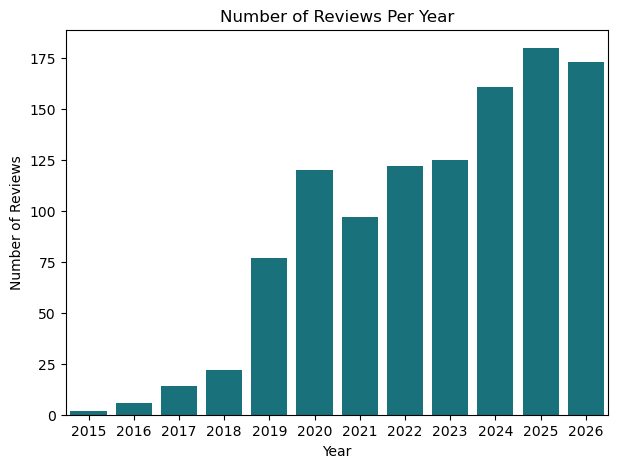

In [93]:
reviews_per_year = df.groupby("year").size().reset_index(name="count")
# print(reviews_every_year)
plt.figure(figsize=(7,5))
sns.barplot(data=reviews_per_year, x="year", y="count", color=colours[1])
plt.title("Number of Reviews Per Year")
plt.ylabel("Number of Reviews")
plt.xlabel("Year")
plt.show()

In [94]:
monthArr = ["January","February","March","April","May","June","July","August","September","October","November","December"]

### *Number of Reviews Per Month*
Number of reviews per month (across all years)\
The first half of the year (january to june) has the most reviews, there are fewer in last half

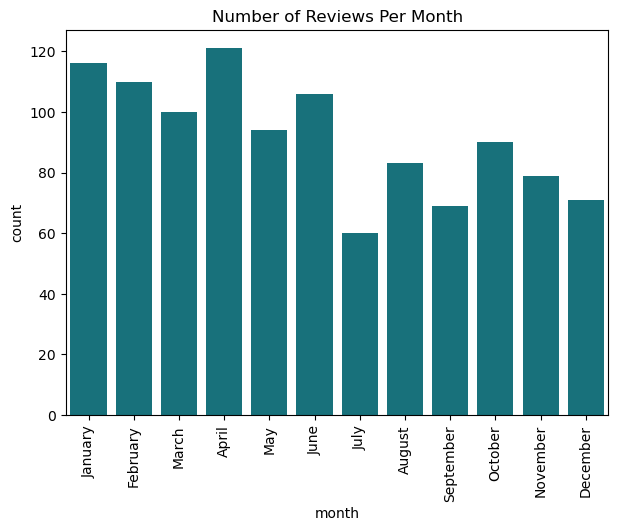

In [95]:
reviews_per_month = df.groupby("month").size().reset_index(name="count")

plt.figure(figsize=(7, 5))
sns.barplot(data=reviews_per_month, x="month", y="count", order=monthArr, color=colours[1])
plt.title("Number of Reviews Per Month")
plt.xticks(rotation=90)
plt.show()

## ii) Rating Distribution

The ratings are skewed towards 1-star and 5-star reviews. People are more inclined to leave reviews when their experiences are very good or terrible. Moreso, people are very likely to leave a review to express their grievences.

There are 798 1-star reviews and 211 5-star reviews.\
2-4 star reviews are between 20 and 36

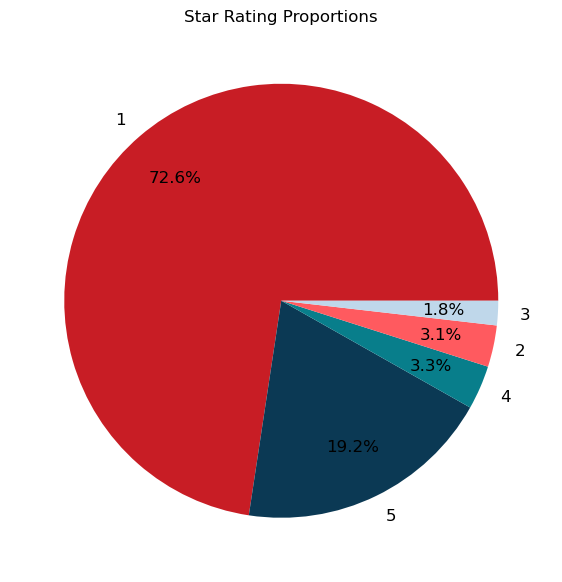

In [96]:
counts = df["stars"].value_counts()
plt.figure(figsize = (7, 8))
plt.pie(counts.values, labels=counts.index, colors=[colmap[i] for i in counts.index], autopct="%1.1f%%", pctdistance=0.75,
     textprops={"fontsize": 12})
plt.title("Star Rating Proportions")
plt.show()

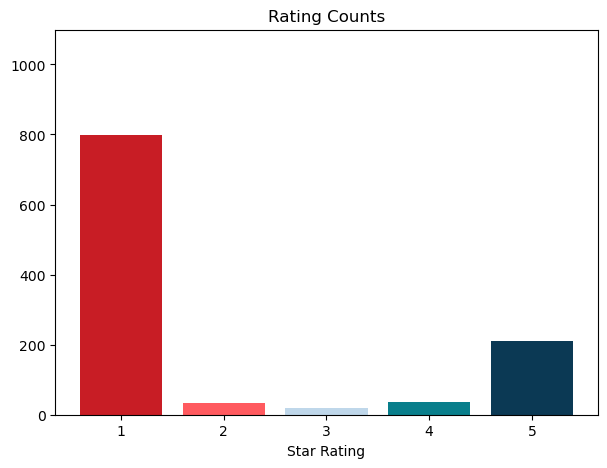

In [97]:
plt.figure(figsize = (7, 5))
plt.bar(counts.index, counts.values, color=[colmap[i] for i in counts.index])
plt.xlabel("Star Rating")
plt.title("Rating Counts")
plt.ylim(0,1099)
plt.show()

### *Average Star Rating Per Year*
2017, 2020, and 2021 seem to be the company's best years:
- 2017 (2.4 ★),
- 2020 (3.0 ★),
- 2021 (2.6 ★)
Ratings dropped from 2.4 stars in 2017 to 1.5 stars in 2019.\
Then ratings increased significanty from 3.0 stars in 2020 to 1.5 stars in 2024

Something went wrong in the 5 year period after 2020, the ratings kept dropping, until 2025 with 2.0 stars.

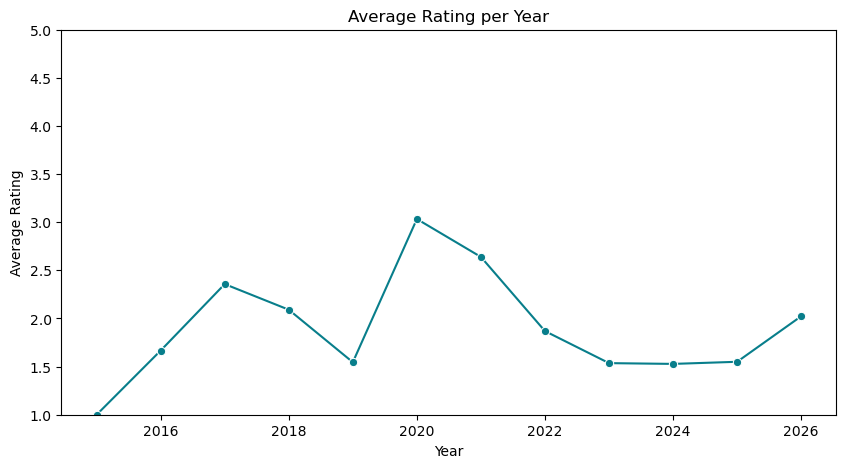

In [98]:
avg_stars_per_year = df.groupby("year")["stars"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=avg_stars_per_year, x="year", y="stars", color=colours[1], marker="o")
plt.title("Average Rating per Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.ylim(1,5)
plt.show()

## iii) Review Text Statistics
Note: review length encompasses word count, character count, sentence count.\
This will reveal how review length is associated with sentiment (star rating).\
These values are based on the raw review text, not the cleaned text

In [99]:
# new dataset for review text counts
df_rs = df[["stars", "word_count"]].copy()
df_rs["char_count"] = df["text"].astype(str).apply(len)
df_rs["sentence_count"] = df["text"].apply(sent_tokenize).apply(len) #tokenise and get count
#df_rs.head()

### *Review Length Correlations*
The correlation matrix shows that review length has a weak negative correlation with the rating. So we would observe that higher word counts are associated with lower ratings, while higher ratings are generally shorter. This indicates that long reviews reflect strong opinions.

This is similar to how 1 star reviews are the most common.

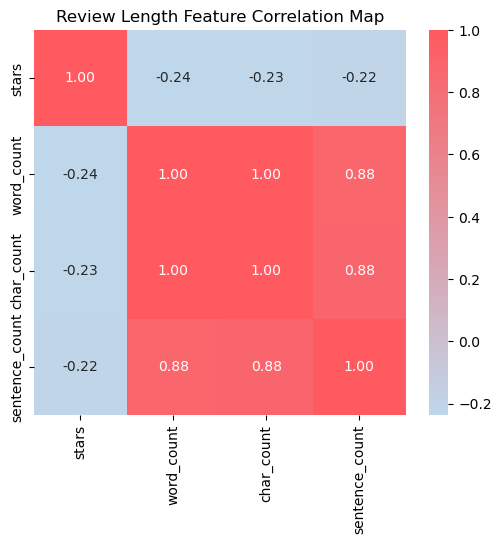

In [100]:
plt.figure(figsize=(6,5))
sns.heatmap(data=df_rs.corr(), annot=True, fmt=".2f", cmap=cust_cmap)
plt.title("Review Length Feature Correlation Map")
plt.show()

### *Review Length by Rating*

- **1-star** reviews are generally the longest: they have the highest average word counts, and largest outliers.
- **2-star** reviews have less, perhaps because people are more inclined to leave 1 star reviews or 3 star reviews
- **3-star** reviews are the second longest. I suppose if people have "mixed feelings" about their experiences with the company may also have a lot to share
- **4-5 star** reviews are the shortest (similar avg) and least variable. People arent as likely to leave huge paragraphs if they have no issues to report

In [101]:
order=[1,2,3,4,5]

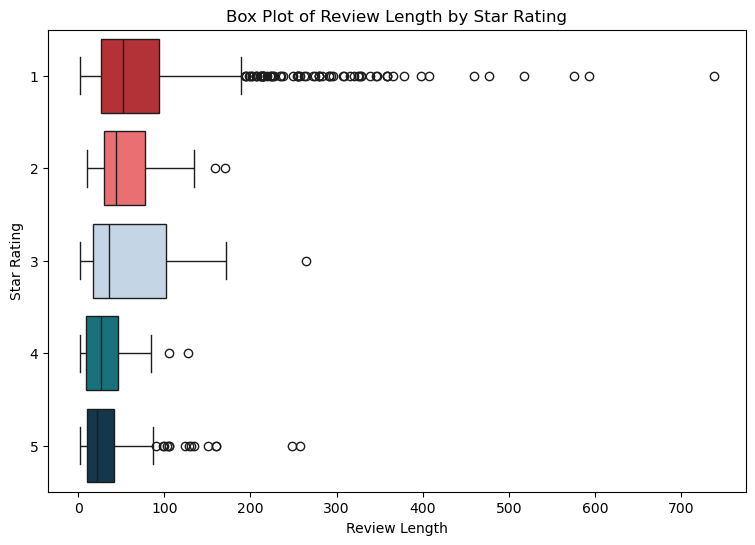

In [102]:
avg_wc_by_stars = df["word_count"].groupby(df["stars"]).mean(numeric_only=True) #average
# print(avg_wc_by_stars)
plt.figure(figsize=(9,6))
sns.boxplot(data=df_rs, x="word_count", y="stars", order=order, hue="stars", legend=False, palette=colmap, orient="h")
plt.title("Box Plot of Review Length by Star Rating")
plt.xlabel("Review Length")
plt.ylabel("Star Rating")

plt.show()

## iv) Word Frequency
N-grams -> used to analyse the relationship between sequences of n consecutive words\
Unigrams, Bigrams, and Trigrams will be analysed

### *Unigrams*
Useful for indentifying common themes\
Lets you create a vocabulary from individual words

In [103]:
# (Praudyog, 2024)
vectoriser1 = CountVectorizer(stop_words="english")
X1 = vectoriser1.fit_transform(df["clean_text"])

# get frequencies (words, word counts)
unigrams = pd.DataFrame({"Unigram": vectoriser1.get_feature_names_out(), "Frequency": X1.sum(axis=0).A1})
unigrams = unigrams.sort_values(by="Frequency", ascending=False)

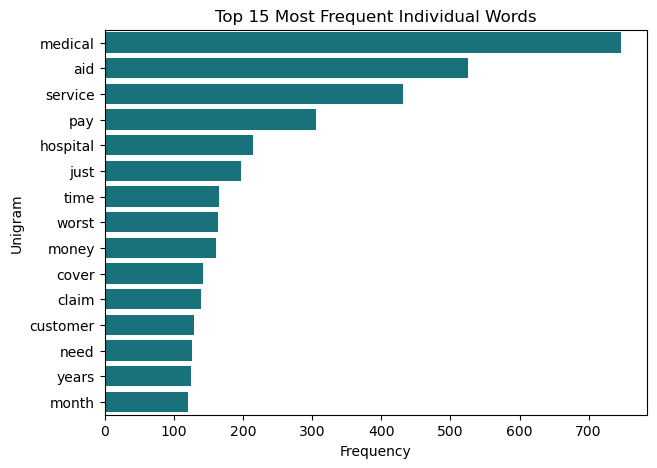

In [104]:
top_unigrams = unigrams.head(15) # will plot the top 15 

plt.figure(figsize=(7,5))
sns.barplot(data=top_unigrams, x="Frequency", y="Unigram", color=colours[1])
plt.title("Top 15 Most Frequent Individual Words")
plt.ylabel("Unigram")
plt.xlabel("Frequency")
plt.show()

### *Bigrams*
More informative than individual words\
Let you create a vocabulary from two word phrases

In [105]:
vectoriser2 = CountVectorizer(stop_words="english", ngram_range=(2,2))
X2 = vectoriser2.fit_transform(df["clean_text"])

bigrams = pd.DataFrame({"Bigram": vectoriser2.get_feature_names_out(), "Frequency": X2.sum(axis=0).A1})
bigrams = bigrams.sort_values(by="Frequency", ascending=False)

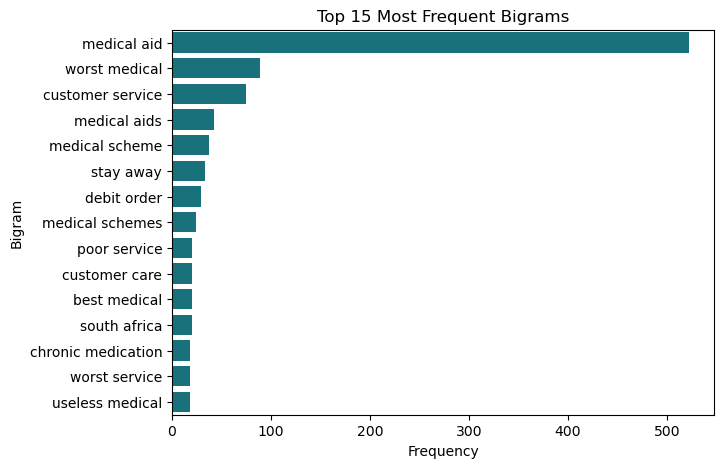

In [106]:
top_bigrams = bigrams.head(15)

plt.figure(figsize=(7,5))
sns.barplot(data=top_bigrams, x="Frequency", y="Bigram", color=colours[1])
plt.title("Top 15 Most Frequent Bigrams")
plt.ylabel("Bigram")
plt.xlabel("Frequency")
plt.show()

### *Trigrams*
Captures full customer issues\
Let you create a vocabulary from three word phrases

In [107]:
vectoriser3 = CountVectorizer(stop_words="english", ngram_range=(3,3))
X3 = vectoriser3.fit_transform(df["clean_text"])

trigrams = pd.DataFrame({"Trigram": vectoriser3.get_feature_names_out(), "Frequency": X3.sum(axis=0).A1})
trigrams = trigrams.sort_values(by="Frequency", ascending=False)

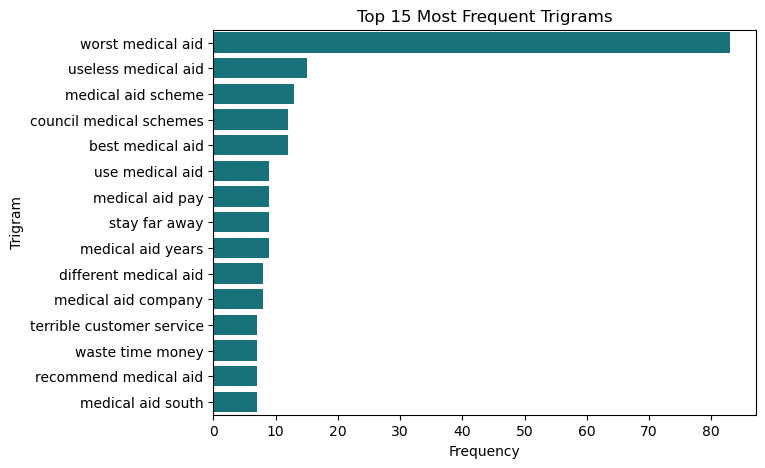

In [108]:
top_trigrams = trigrams.head(15)

plt.figure(figsize=(7,5))
sns.barplot(data=top_trigrams, x="Frequency", y="Trigram", color=colours[1])
plt.title("Top 15 Most Frequent Trigrams")
plt.ylabel("Trigram")
plt.xlabel("Frequency")
plt.show()

## Create Sentiment Labels
Since the dataset is unlabelled and only has star ratings, they will be used as proxy sentiment labels. This will make the sentiment analyisis a binary classification task.

1-2 star ratings will be considered negative,
4-5 star ratings will be considered positive

There are only twenty 3 star reviews, which is not sufficient to make a "neutral" class. Moreover, these reviews may be more nuanced with mixed feelings so they cannot simply be placed in the negative category. It would introduce noise to the negative category, megatively impacting the model's ability to separate. Removing them is more efficient than trying to oversample and increase chances of overfitting

In [109]:
df = df[df["stars"] !=3].copy() # remove 3 star reviews
print(f"{len(df)} reviews left")

1079 reviews left


In [110]:
def create_sentiment(stars):
    if stars >= 4:
        return "positive"
    else:
        return "negative"

In [111]:
df["sentiment"] = df["stars"].apply(create_sentiment)

In [112]:
clrs = [colours[1], colours[3]]

### *Sentiment Class Distribution*
The class imbalance is quite severe, as expected from the distribution of star ratings before. 77.1% of the reviews are "negative", while only 22.9% are positive.

This would reduce a model's ability to correctly identify positive reviews, while only performing well on negative reviews.

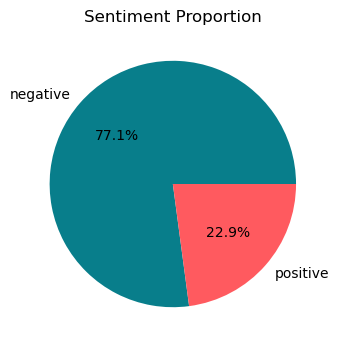

In [113]:
counts = df["sentiment"].value_counts()
fig = plt.figure(figsize = (7, 4))
plt.pie(counts.values, labels=counts.index, colors=clrs, autopct="%1.1f%%")
plt.title("Sentiment Proportion")
plt.show()

### *Sentiments Over the Years*
The reviews in most years are predominently negative. Negative reviews far outweigh positive reviews.
However, we see that 2020 was a good year. There are more positive reviews than negative reviews, and the most positive reviews out of any other year. 

In [114]:
sentiment_years = df.groupby(["year", "sentiment"]).size().reset_index(name="count")

In [115]:
sentmap = {"positive": colours[1], "negative": colours[3]}

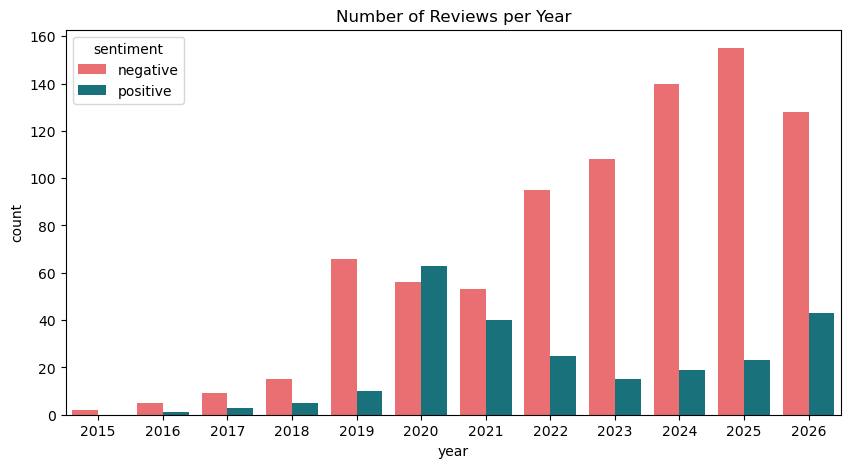

In [116]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="year", hue="sentiment", palette=sentmap)
plt.title("Number of Reviews per Year")
plt.show()

---
# 3. PREPROCESSING
Further preprocessing to prepare the data for modelling:
removing stop words, maintaining negations, removing domain words like "medical" or "scheme".

Negation handling was addressed by simply retaining negation words like "no" or "not". It makes sure that sentiments are still maintained. "not happy" would become "happy" without exluding these negations from the stopword removal.
Initially, this was left out for the purpose of topic analysis so that these words did not dominate, it was then included for sentiment analysis

## Stopwords, Lemmatisation, Tokenisation
**Stop word removal:** common words (like “the”, “and” “a”) were removed because they have no semantic value (GeeksforGeeks, 2026). Words like “medical”, “aid” and “scheme” that frequently appeared were also removed because they do not help distinguish between topics and sentiments.\
**Negation handling:** common negation words like “no”, “nor”, “not” were excluded from the stop word list. This ensures that phrases like “not helpful” retain their negative meaning.\
**Lemmatisation:** words are reduced to their base form to reduce vocabulary size while preserving the meaning of words (Van Otten, 2023).\
**Tokenisation:** each review was split into individual word tokens (GeeksforGeeks, 2026) enabling the use of feature extraction methods like TF-IDF or n-grams.\
**Label encoding:** sentiment labels were encoded into binary values, a form the models can process. This translated “negative” into a 0 and “positive” into a 1. 

In [117]:
custom_stopwords = {"medical", "aid", "scheme", "insurance"}
stop_words = set(stopwords.words("english")).union(custom_stopwords)
lemmatizer = WordNetLemmatizer()

def preprocessing(text):
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [118]:
def tokenise(text):
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return tokens

In [119]:
df["processed_text"] = df["clean_text"].apply(preprocessing)
df["tokens"] = df["clean_text"].apply(tokenise)

## Encode Sentiment Labels

In [120]:
lb = LabelEncoder()
df["sentiment"] = lb.fit_transform(df["sentiment"])

## Word Clouds
Now that the remaining preprocessing tasks have been done, word clouds can be created.

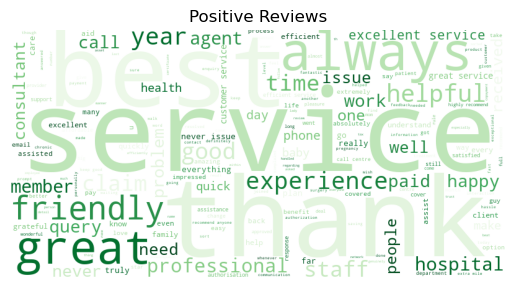

In [121]:
pos_rev_words = " ".join([" ".join(tokens) for tokens in df[df["sentiment"] == 1]["tokens"]])

wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="Greens").generate(pos_rev_words)
plt.title("Positive Reviews")
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

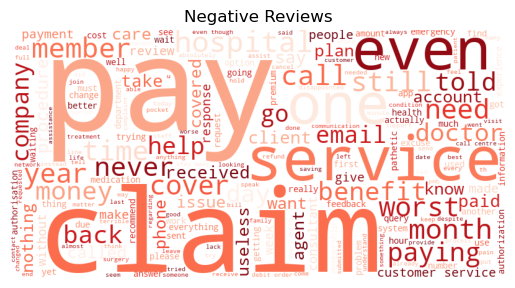

In [122]:
neg_rev_words = " ".join([" ".join(tokens) for tokens in df[df["sentiment"] == 0]["tokens"]])

wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="Reds").generate(neg_rev_words)
plt.title("Negative Reviews")
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [123]:
topic_colours = ["#0B2954", "#FF5A5F", "#703D57", "#087E8B"]

---
# 4. TOPIC MODELLING PIPELINE
Now that the remaining preprocessing have been done a topic modelling pipeline can be created

## Baseline LDA Model

In [124]:
# (GeeksforGeeks, 2020b)
lda_pipeline = Pipeline([
    ("vectorizer", CountVectorizer(max_df=0.90, min_df=5, ngram_range=(1,1))),
    ("lda", LatentDirichletAllocation(n_components=4, random_state=42, learning_method="batch"))
])

The pipeline automatically vectorises the text then fits an LDA model\
Vectorisation -> ignores words that are in more than 90% of reviews (generic), ignore words that are in less than 5 reviews (remove noise) 

Since this is not sentiment analysis all stop_words were removed (negations do not need to be preserved)

In [125]:
# fit pipeline
lda_pipeline.fit(df["processed_text"])

,steps,"[('vectorizer', ...), ('lda', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


## Get Dominant Topics
(scikit-learn.org, n.d.)

In [126]:
lda_vectoriser = lda_pipeline.named_steps["vectorizer"]
lda_model = lda_pipeline.named_steps["lda"]

features = lda_vectoriser.get_feature_names_out()

In [127]:
for i, topic in enumerate(lda_model.components_):
    words = [features[j] for j in topic.argsort()[-10:][::-1]]
    print(f"Topic {i+1}: {", ".join(words)}")

Topic 1: pay, month, money, year, paying, still, call, get, even, account
Topic 2: service, get, call, claim, time, phone, one, email, back, customer
Topic 3: service, always, would, worst, star, ever, great, even, hospital, give
Topic 4: hospital, year, pay, would, received, member, procedure, service, claim, never


## Topic Modelling Outcomes
Topic labels were given based on the top words
- **"Billing & Payment":** this topic focused on recurring payments, money, and billing-related concerns.
- **"Claims & Communications":** this topic revolves around claims, communication channels, response times, and customer service.
- **"Customer Service":** this topic contains evaluative words like ("worst", "great", "star") that reflect customer satisfaction/ dissatisfaction rather than a specific issue, but this highlights customer service issues.
- **"Hospital & Benefits":** this topic focuses on hospital-related services/ procedures/ claims, suggesting issues with healthcare access and benefit administration.

In [128]:
topic_probabilities = lda_pipeline.transform(df["processed_text"]) 
df["main_topics"] = topic_probabilities.argmax(axis=1)

In [129]:
topic_labels = {
    0: "Billing & Payments", 1: "Claims & Communications",
    2: "Customer Service", 3: "Hospital & Benefits"
}
df["topic_label"] = df["main_topics"].map(topic_labels)

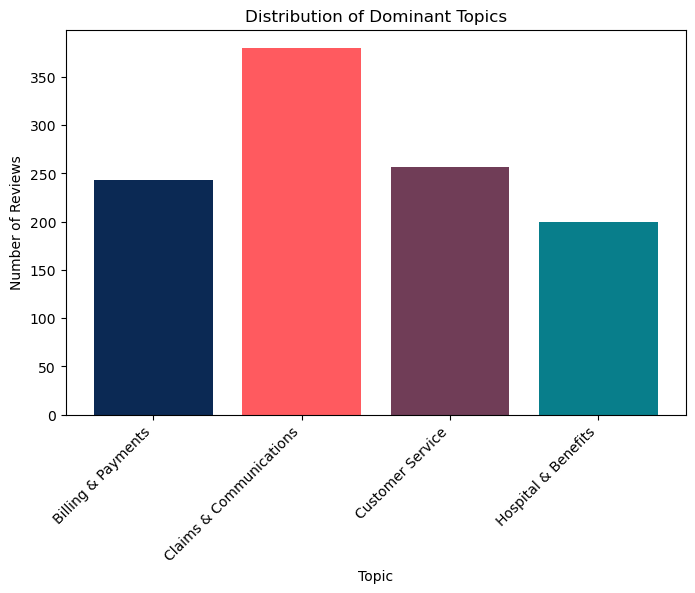

In [130]:
topic_counts = df["main_topics"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(topic_counts.index.map(topic_labels), topic_counts.values, color=[topic_colours[i] for i in topic_counts.index])

plt.xlabel("Topic")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Dominant Topics")
plt.xticks(rotation=45, ha="right")

plt.show()

The distribution of reviews across topics indicates that the most frequently discussed areas of concern are Claims and Communication (with 380 reviews), then Customer Service (with 256 reviews), Billing and Payments (with 243 reviews) and Hospital and Benefits (with 200 reviews).\
This shows that customer concerns are mainly on the claims process and communication with the medical aid provider. 

The dominant terms under claims and communications indicate that customers frequently face issues with contacting the provider, delays in responses, and difficulties in claims processing. Similarly, the customer service topic contains opinionated language with words like 'worst', 'ever', and 'great' suggesting both passionate feedback and inconsistency in service experiences. 

The billing and payments topic highlights financial concerns with words like "pay", "money", "account" and "month" suggesting issues with payment and billing. Lastly, the hopsital and benefits topic reflects more procedural concerns with words like "hospital", "procedure", "member" suggesting issues related to coverage, approvals and access to healthcare services.

Overall, customer dissatisfaction comes from administrative and communication related issues, with claims processing and customer support as main areas of concern.

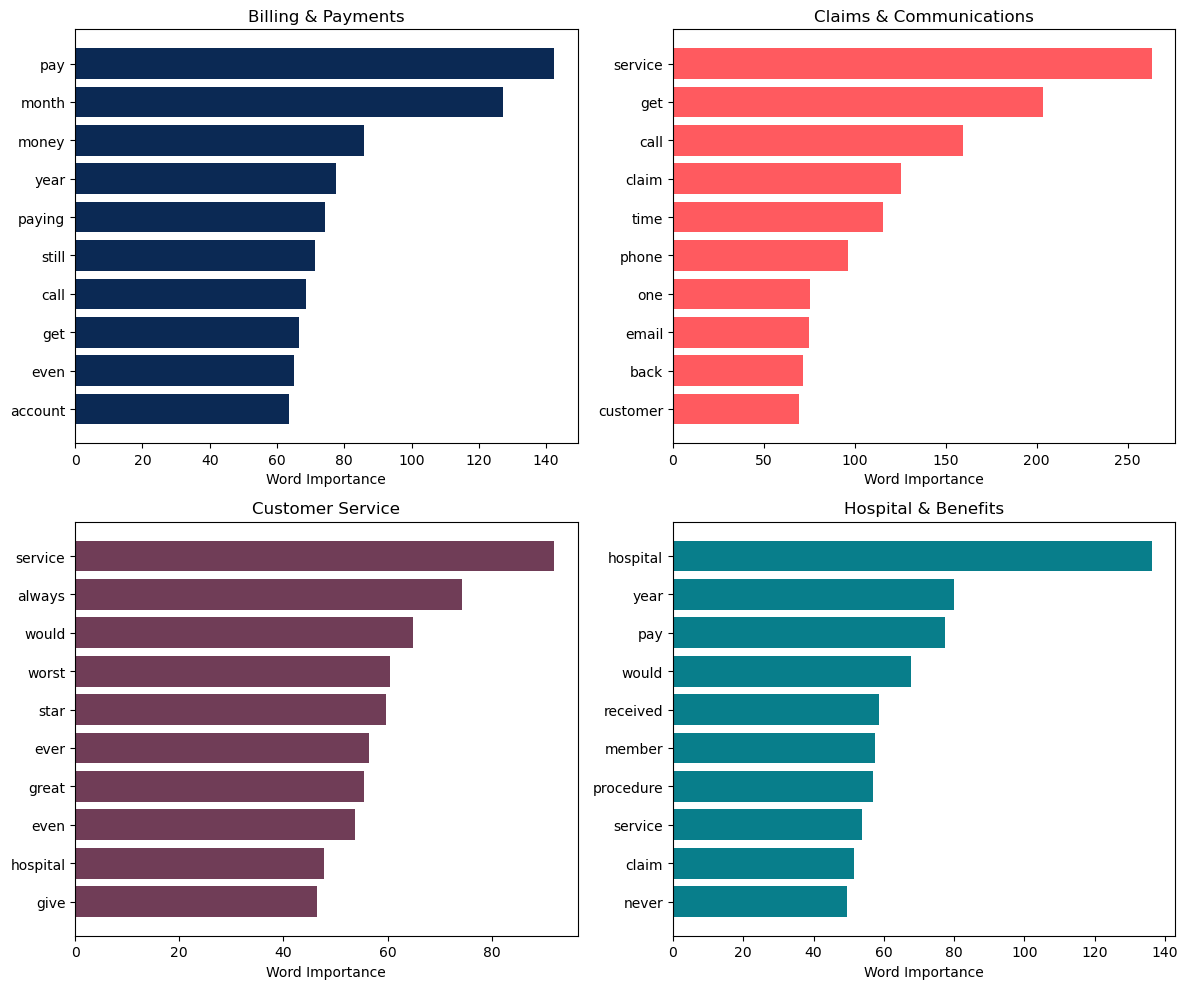

In [131]:
fig, axes = plt.subplots(2,2, figsize=(12, 10))
axes = axes.flatten()

for topic_idx, topic in enumerate(lda_model.components_):
    top_features_ind = topic.argsort()[:-11:-1]
    top_features = [features[i] for i in top_features_ind]
    weights = topic[top_features_ind]
    
    axes[topic_idx].barh(top_features[::-1], weights[::-1], color=topic_colours[topic_idx])
    axes[topic_idx].set_title(topic_labels[topic_idx])
    axes[topic_idx].set_xlabel("Word Importance")

plt.tight_layout()
plt.show()

## Hyperparameter Tuning
GridSearchCV was used to explore different hyperparameter combinations, However, the optimal model performed similar to the baseline. So the original configuration was already perfect for this dataset

In [132]:
param_grid = {
    "vectorizer__max_df": [0.85, 0.90, 0.95],
    "vectorizer__min_df": [2, 5],
    "lda__n_components": [4, 5, 6, 7, 8],
    "lda__learning_decay": [0.5, 0.7, 0.9]
}

grid = GridSearchCV(lda_pipeline, param_grid=param_grid, cv=5, n_jobs=-1)

In [133]:
grid.fit(df["processed_text"])

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'lda__learning_decay': [0.5, 0.7, ...], 'lda__n_components': [4, 5, ...], 'vectorizer__max_df': [0.85, 0.9, ...], 'vectorizer__min_df': [2, 5]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [134]:
print(f"Best hyperparameters: {grid.best_params_}\n")
print(f"Best Score: {grid.best_score_}")
print(f"Original Model Score: {lda_pipeline.score(df["processed_text"])}")

Best hyperparameters: {'lda__learning_decay': 0.5, 'lda__n_components': 4, 'vectorizer__max_df': 0.85, 'vectorizer__min_df': 5}

Best Score: -36237.14441353742
Original Model Score: -176679.66392732208


These are similar to the original, so there is no need to fit the model

---

# 5. SENTIMENT ANALYSIS PIPELINE

The preprocessing for this section is slightly different, the negation words are not removed because they are needed to preserve semantic meaning.

In [135]:
negations = {"no", "not", "nor"}
stop_words_sentiment = set(stopwords.words("english")).union(custom_stopwords)

def preprocess_sentiment(text):
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words_sentiment]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [136]:
df["processed_sentiment"] = df["clean_text"].apply(preprocess_sentiment)

In [137]:
df.head()

,stars,text,publishedAtDate,language,clean_text,word_count,month,year,sentiment,processed_text,tokens,main_topics,topic_label,processed_sentiment
1,1,Discovery Medical Aid continues to prove that ...,2026-05-25 13:48:25.154000+00:00,en,medical aid continues to prove that patient h...,114,May,2026,0,continues prove patient health secondary profi...,"[continues, prove, patient, health, secondary,...",0,Billing & Payments,continues prove patient health secondary profi...
2,1,This company cannot even get a simple app righ...,2026-05-15 12:50:28.282000+00:00,en,this company cannot even get a simple app righ...,46,May,2026,0,company cannot even get simple app right set c...,"[company, cannot, even, get, simple, app, righ...",2,Customer Service,company cannot even get simple app right set c...
3,1,"If you are considering Discovery Health, speci...",2026-04-09 14:52:34.298000+00:00,en,if you are considering health specifically th...,189,April,2026,0,considering health specifically keycare plan s...,"[considering, health, specifically, keycare, p...",3,Hospital & Benefits,considering health specifically keycare plan s...
4,1,I joined the Blood Pressure Challenge on 21 Ma...,2026-03-30 04:43:28.754000+00:00,en,i joined the blood pressure challenge on march...,86,March,2026,0,joined blood pressure challenge march within w...,"[joined, blood, pressure, challenge, march, wi...",0,Billing & Payments,joined blood pressure challenge march within w...
7,1,"Hi Discovery,\n\nFirstly I’d like to start by ...",2026-03-24 13:25:48.207000+00:00,en,hi firstly i would like to start by saying i ...,181,March,2026,0,hi firstly would like start saying never issue...,"[hi, firstly, would, like, start, saying, neve...",2,Customer Service,hi firstly would like start saying never issue...


## Train/Test Split

In [138]:
X = df["processed_text"]
y = df["sentiment"]

In [139]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Baseline Naive Bayes Model
Multinomial Naive Bayes model trained on the processed text data\
TF-IDF was used to reduce the impact of frequently occurring but less informative words while preserving discriminative terms.

In [140]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_df=0.9, min_df=5, ngram_range=(1,2))),
    ("nb", MultinomialNB())
])

In [141]:
nb_pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('nb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [142]:
nb_pred = nb_pipeline.predict(X_test)

### *Baseline NB Evaluation*
F1-score was selected as the primary evaluation metric due to class imbalance and the importance of balancing precision and recall.
False negatives (misclassified negative reviews) are particularly critical as they may conceal customer dissatisfaction and prevent timely service improvements.

In [143]:
print("Naive Bayes Classification Report")
print(classification_report(y_test, nb_pred))

Naive Bayes Classification Report
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       167
           1       1.00      0.49      0.66        49

    accuracy                           0.88       216
   macro avg       0.93      0.74      0.79       216
weighted avg       0.90      0.88      0.87       216



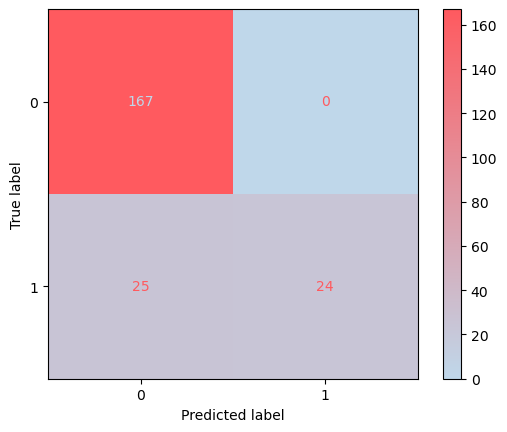

In [144]:
ConfusionMatrixDisplay.from_predictions(y_test, nb_pred, cmap=cust_cmap)

### *Naive Bayes Hyperparameter Tuning*
Hyperparameter tuning done using Grid Search since the search space is fairly small.

The TF-IDF parameters control vocabulary filtering, and class distribution assumptions\
The NB parameters control smoothing and class distribution assumptions

In [151]:
param_grid = {
    "tfidf__max_df": [0.85, 0.9],
    "tfidf__min_df": [2, 5],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__sublinear_tf": [True, False],
    "nb__alpha": [0.1, 0.5, 1.0, 2.0]
}

In [152]:
grid = GridSearchCV(nb_pipeline, param_grid, cv=5, scoring="f1", n_jobs=-1)

In [153]:
grid.fit(X_train, y_train)

,estimator,Pipeline(step...inomialNB())])
,param_grid,"{'nb__alpha': [0.1, 0.5, ...], 'tfidf__max_df': [0.85, 0.9], 'tfidf__min_df': [2, 5], 'tfidf__ngram_range': [(1, ...), (1, ...)], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [155]:
best_nb = grid.best_estimator_

In [156]:
best_nb_pred = best_nb.predict(X_test)

In [157]:
print("Tuned Naive Bayes Classification Report")
print(classification_report(y_test, best_nb_pred))

Tuned Naive Bayes Classification Report
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       167
           1       1.00      0.65      0.79        49

    accuracy                           0.92       216
   macro avg       0.95      0.83      0.87       216
weighted avg       0.93      0.92      0.91       216



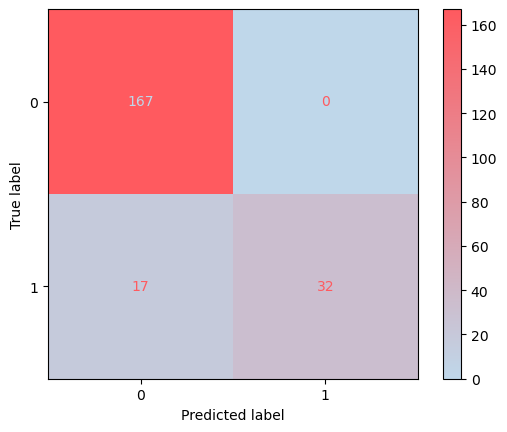

In [158]:
ConfusionMatrixDisplay.from_predictions(y_test, best_nb_pred, cmap=cust_cmap)

### *Conclusion on NB Models*
The tuned Naive Bayes model performs better across all evaluation metrics
The model's accuracy improved to 0.92 from 0.88. The performance on positive reviews also increased slightly. Recall (on positive class) increased to 0.65 from 0.49 and F1-score improved to 0.79 from 0.66. It maintained accuracy on the negative class, correctly classifying all cases

## Logistic Regression for Comparison
Naive Bayes does not have ``class_weight``. Logistic Regression is another option, and it does have class weight. Since the class imbalance is quite severe, this will be very useful for model performance


To address class imbalance in the sentiment dataset, class weighting was applied during model training to penalise misclassification of the minority class more heavily. This approach ensures that the model does not become biased towards the majority class. Additionally, evaluation metrics such as F1-score and recall were prioritised over accuracy to provide a more balanced assessment of model performance.

In [159]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_df=0.9, min_df=5, ngram_range=(1,2))),
    ("lr", LogisticRegression(class_weight="balanced"))
])

In [160]:
lr_pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [161]:
lr_pred = lr_pipeline.predict(X_test)

In [162]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, lr_pred))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       167
           1       0.88      0.86      0.87        49

    accuracy                           0.94       216
   macro avg       0.92      0.91      0.91       216
weighted avg       0.94      0.94      0.94       216



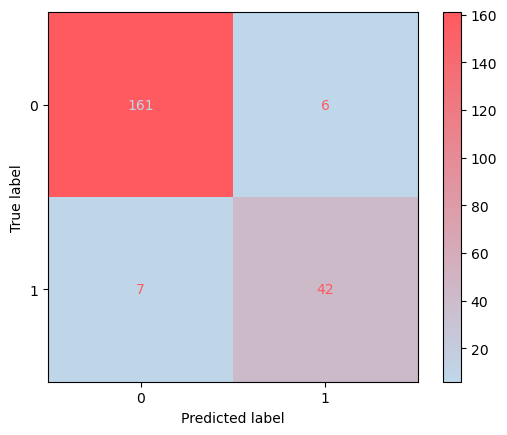

In [163]:
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, cmap=cust_cmap)

Logistic Regression with class weighting is the best performing model overall.

## Hyperparameter Tuning
The Logistic Regression model performs better on the minority class, but worse on the majority class.

In [164]:
param_grid = {
        "lr__solver": ["liblinear"],
        "lr__penalty": ["l1", "l2"],
        "lr__C": np.logspace(-4, 4, 20),
        "lr__max_iter": [100, 1000]
    }

In [165]:
grid = GridSearchCV(lr_pipeline, param_grid, cv=5, scoring="f1", n_jobs=-1)

In [166]:
grid.fit(X_train, y_train)

,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'lr__C': array([1.0000...00000000e+04]), 'lr__max_iter': [100, 1000], 'lr__penalty': ['l1', 'l2'], 'lr__solver': ['liblinear']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [167]:
print(f"Best hyperparameters: {grid.best_params_}\n")
print(f"Best Score (F1): {grid.best_score_}")

Best hyperparameters: {'lr__C': np.float64(29.763514416313132), 'lr__max_iter': 100, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}

Best Score (F1): 0.8285920535920536


In [168]:
best_lr = grid.best_estimator_

In [169]:
best_lr_pred = best_lr.predict(X_test)

In [170]:
print("Tuned Logistic Regression Classification Report")
print(classification_report(y_test, best_lr_pred))

Tuned Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       167
           1       0.85      0.80      0.82        49

    accuracy                           0.92       216
   macro avg       0.89      0.88      0.89       216
weighted avg       0.92      0.92      0.92       216



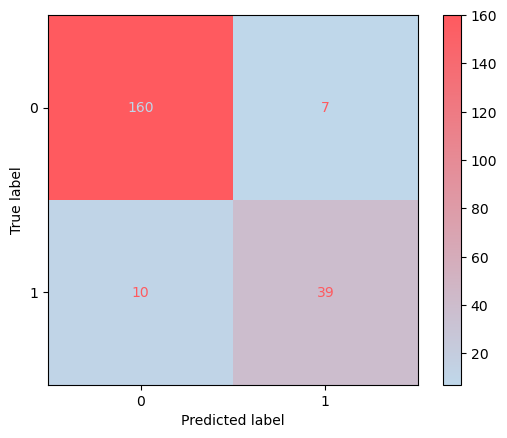

In [171]:
ConfusionMatrixDisplay.from_predictions(y_test, best_lr_pred, cmap=cust_cmap)

## Final Performance Compairsons
### *Best Naive Bayes vs Best Logistic Regression ROC-AUC*
AUC measures how well the model distinguishes between positive and negative classes regardless of class imbalance. It measures performance across all thresholds so the score is not inflated by the model's performance on the majority class

In [189]:
# predicted probabilites
nb_proba = nb_pipeline.predict_proba(X_test)[:,1]
best_nb_proba = best_nb.predict_proba(X_test)[:,1]

lr_proba = lr_pipeline.predict_proba(X_test)[:,1]
best_lr_proba = best_lr.predict_proba(X_test)[:,1]

In [192]:
#auc scores
nb_auc = roc_auc_score(y_test, nb_proba)
print(f"Naive Bayes ROC-AUC Score: {nb_auc:.3f}")

best_nb_auc = roc_auc_score(y_test, best_nb_proba)
print(f"Tuned Naive Bayes ROC-AUC Score: {best_nb_auc:.3f}")

lr_auc = roc_auc_score(y_test, lr_proba)
print(f"Logistic Regression ROC-AUC Score: {lr_auc:.3f}")

best_lr_auc = roc_auc_score(y_test, best_lr_proba)
print(f"Tuned Logistic Regression ROC-AUC Score: {best_lr_auc:.3f}")

Naive Bayes ROC-AUC Score: 0.980
Tuned Naive Bayes ROC-AUC Score: 0.981
Logistic Regression ROC-AUC Score: 0.982
Tuned Logistic Regression ROC-AUC Score: 0.964


#### ROC Curves
ROC curve for the strongest NB model LR models

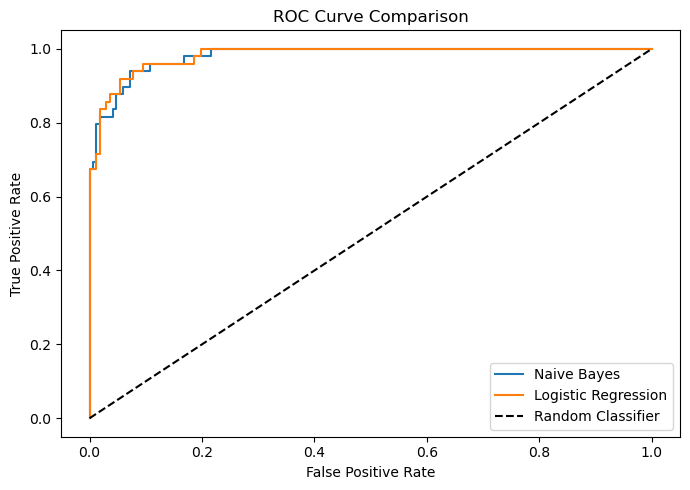

In [197]:
# plot curves on same axes
nb_fpr, nb_tpr, _ = roc_curve(y_test, best_nb_proba)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)

plt.figure(figsize=(7,5))
plt.plot(nb_fpr, nb_tpr, label="Naive Bayes")
plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], "k--", label="Random Classifier")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

X-axis -> FPR -> how many positive reviews are incorrectly labelled as negative\
Y-axes -> TPR -> how many negative reviews are correctly identified

Therefore the curve should ideally be as close to the top left corner as possible. This is a model that catches almost all true negatives while producing very few false alarms.

Both models achieved near identical AUC scores (NB = 0.981, LR = 0.982). They both perform well at discrimination. The LR model still showed superior performance on F1 score and recall, making it preferred, given the class imbalance.

In [195]:
df_comparison = pd.DataFrame({
    "Precision": [precision_score(y_test, nb_pred), precision_score(y_test, best_nb_pred), precision_score(y_test, lr_pred), precision_score(y_test, best_lr_pred)],
    "Recall": [recall_score(y_test, nb_pred), recall_score(y_test, best_nb_pred), recall_score(y_test, lr_pred), recall_score(y_test, best_lr_pred)],
    "Weighted F1 Score": [f1_score(y_test, nb_pred, average="weighted"), f1_score(y_test, best_nb_pred, average="weighted"), f1_score(y_test, lr_pred, average="weighted"), f1_score(y_test, best_lr_pred, average="weighted")],
    "AUC Score": [nb_auc, best_nb_auc, lr_auc, best_lr_auc],
    "TP (positive sentiment)": ["24/49", "32/49", "42/49", "39/49"],
    "TN (negative sentiment)": ["167/167", "167/167", "161/167", "160/167"]
}, index=["Default NB", "Tuned NB", "Default LR", "Tuned LR"])

In [196]:
df_comparison

,Precision,Recall,Weighted F1 Score,AUC Score,TP (positive sentiment),TN (negative sentiment)
Default NB,1.000000,0.489796,0.868471,0.980325,24/49,167/167
Tuned NB,1.000000,0.653061,0.914943,0.981303,32/49,167/167
Default LR,0.875000,0.857143,0.939594,0.982403,42/49,161/167
Tuned LR,0.847826,0.795918,0.920404,0.964438,39/49,160/167


# Conclusion
The default Logistic Model is the best model.\
It has the most balanced metrics:
- Recall score of 0.86 -> gets 42/49 positive reviews (highest recall among models)
- F1 score of 0.94 -> best overall, meaning precision and recall are well balanced
- AUC score of 0.98 -> it has almost perfect discrimination

The precision score the NB models get (1.0) are misleading. It means that the model is being overly conservative by only predicting positive when its almost certain. This is why the recall is poor and these models aren't the most useful in practice.

The tuned LR model actually performs worse than the default one. The tuning dropped all metrics.

Since the main business objective is identifying negative reviews, the model needs to reliably detect true cases without missing too many, hence recall and F1 score are the main metrics. The default model wins on both of these, making it the best choice

# Reference List